In [14]:
## Section A: Define Functions ##

import numpy as np
import matplotlib.pyplot as plt
import os

def thetafunc(phi, we,n): # define theta
    return (1-phi)*(n-1)/(n*phi)

def solve_G(we, wu, phi, n): # this function derives z (>1) using parameters; it may generate multiple solutions
    a = we/wu
    theta = thetafunc(phi, we, n)
    A = 2*a - 1 - 2*theta
    B = a*a - 2*a
    C = -a*a
    roots = np.roots([1, A, B, C])
    real_roots = sorted([float(r.real) for r in roots if np.isreal(r) and r.real > 1])
    return real_roots

def U(z, wu, ws, we, cs, gamma, n):
    theta = thetafunc(phi, we,n)
    u = np.sqrt(ws)*phi*(1+theta)*np.sqrt(z*wu)/(1+z) - cs*(we**gamma)
    return u

def theta_cutoff(we, wu):
    h = wu / we
    a_coeff = 8 * (h**3)
    b_coeff = h * (8 * h * h - 20 * h - 1)
    c_coeff = 2 * ((1 + h)**3)
    t0 = 27 / (16 * h)
    th, tl = t0, t0

    if we > 8 * wu:
        D = b_coeff**2 - 4 * a_coeff * c_coeff
        if D >= 0:
            tl = 0.5 * (-b_coeff - np.sqrt(D)) / a_coeff
            th = 0.5 * (-b_coeff + np.sqrt(D)) / a_coeff

    return th, tl

def we_cutoff(phi, wu, n, we_grid):
    theta_line = np.full(len(we_grid), np.nan)
    th_line = np.full(len(we_grid), np.nan)
    tl_line = np.full(len(we_grid), np.nan)
    for i, we in enumerate(we_grid):
        th, tl = theta_cutoff(we, wu)
        th_line[i] = th
        tl_line[i] = tl
        theta_line[i] = (n-1)*(1-phi)/(phi*n)
    
    
    cross_th = []
    diff_th = theta_line - th_line
    diff_tl = theta_line - tl_line

    for i in range(len(we_grid)-1):
        if np.isnan(diff_th[i]) or np.isnan(diff_th[i+1]):
            continue
        if diff_th[i] * diff_th[i+1] < 0:
            # linear prox
            w = we_grid[i] - diff_th[i] * (we_grid[i+1]-we_grid[i]) / (diff_th[i+1]-diff_th[i])
            cross_th.append(w)
            break
    cross_tl = []
    for i in range(len(we_grid)-1):
        if np.isnan(diff_tl[i]) or np.isnan(diff_tl[i+1]):
            continue
        if diff_tl[i] * diff_tl[i+1] < 0:
            w = we_grid[i] - diff_tl[i] * (we_grid[i+1]-we_grid[i]) / (diff_tl[i+1]-diff_tl[i])
            cross_tl.append(w)
            break
    return cross_th[0], cross_tl[0]

def result(cs, ws, wu, phi, ws_grid, r, we_grid, gamma, n):
    
    z_min = np.full(len(we_grid), np.nan)
    z_max = np.full(len(we_grid), np.nan)

    for i, we_val in enumerate(we_grid):
        roots = solve_G(we_val, wu, phi, n) # this roots are expressed in the form of z
        if roots:
            z_min[i] = np.min(roots)
            z_max[i] = np.max(roots)
    
    # == Optimal we == #
    we_star = np.full(len(ws_grid), np.nan)
    u_star = np.full(len(ws_grid), np.nan)

    for j, ws_val in enumerate(ws_grid):
        u_min = U(z_min, wu, ws_val, we_grid, cs, gamma,n)
        u_max = U(z_max, wu, ws_val, we_grid, cs, gamma,n)
        u_av = r * u_min + (1 - r) * u_max
        
        if not np.all(np.isnan(u_av)):
            idx = np.nanargmax(u_av)
    
            # 最適な we の値を記録
            we_star[j] = we_grid[idx]

    return we_star, ws_grid
    
    
## Plot Function (broken axis figure) 
def draw_broken_axis(ax_top, ax_bot, x, y, title, y_lim, r, loc):
    # 1. ジャンプ箇所の検知
    threshold = (y_lim[3] - y_lim[0]) * 0.1
    jump_indices = np.where(np.abs(np.diff(y)) > threshold)[0]
    #jump_indices2 = np.where(np.abs(np.diff(y2)) > threshold)[0]
    
    # 2. 実線の描画（nanで分断）
    x_split = np.insert(x.astype(float), jump_indices + 1, np.nan)
    y_split = np.insert(y.astype(float), jump_indices + 1, np.nan)
    
    #x2_split = np.insert(x.astype(float), jump_indices2 + 1, np.nan)
    #y2_split = np.insert(y2.astype(float), jump_indices2 + 1, np.nan)
    
    msize_main = 2
    msize_thre = 6
    for ax in [ax_top, ax_bot]:
        #if ax == ax_top:
        ax.plot(x_split, y_split, 'b-', markevery=100, lw = 2., zorder=2, label = f'$\\rho = {r}$')
        #ax.plot(x2_split, y2_split, 'r--', markevery = 1000, lw = 1.5, zorder=2, label = f'$\\rho = {r2}$')
        #elif ax == ax_bot:
            #ax.plot(x_split, y_split, 'b-', markevery=100, lw = 2., zorder=2)
            #ax.plot(x2_split, y2_split, 'r--', markevery = 1000, lw = 1.5, zorder=2)
        
        # 3. ジャンプ前後の端点に黒丸をプロット
        # 各ジャンプ点 idx (前) と idx+1 (後) をプロット
        for idx in jump_indices:
            # ジャンプ前
            ax.plot(x[idx], y[idx], 'bo', markersize=msize_thre, zorder=3)
            # ジャンプ後
            ax.plot(x[idx+1], y[idx+1], 'bo', markersize=msize_thre, zorder=3)
            
            # 4. 縦の点線
            ax.vlines(x[idx], y[idx], y[idx+1], colors='blue', linestyles='dotted', lw=1, zorder=1)
        #for idx in jump_indices2:
            # ジャンプ前
            #ax.plot(x[idx], y2[idx], 'ro', markersize=msize_thre, zorder=3)
            # ジャンプ後
            #ax.plot(x[idx+1], y2[idx+1], 'ro', markersize=msize_thre, zorder=3)
            
            # 4. 縦の点線
            #ax.vlines(x[idx], y2[idx], y2[idx+1], colors='red', linestyles='dotted', lw=1, zorder=1)

    # 軸の設定、省略線の描画（前述の Figure 座標のロジック）
    ax_bot.set_ylim(y_lim[0], y_lim[1])
    ax_top.set_ylim(y_lim[2], y_lim[3])
    ax_top.spines['bottom'].set_visible(False)
    ax_bot.spines['top'].set_visible(False)
    ax_top.tick_params(labelbottom=False, bottom=False)
    ax_top.spines['right'].set_visible(False)
    ax_top.spines['top'].set_visible(False)
    ax_bot.spines['right'].set_visible(False)
    #ax_bot.spines['top'].set_visible(False)

    fig = plt.gcf()
    d = 0.005 
    for ax in [ax_top, ax_bot]:
        for side in [0]:
            pos = ax.transAxes.transform([side, 0 if ax == ax_top else 1])
            pos_fig = fig.transFigure.inverted().transform(pos)
            fig.lines.append(plt.Line2D(
                (pos_fig[0]-d, pos_fig[0]+d), (pos_fig[1]-d, pos_fig[1]+d), 
                transform=fig.transFigure, color='k', lw=1))

    # --- 凡例の配置 ---
    # 重複を避けるため、ハンドルのリストから一組だけ取得して配置
    # loc='upper left' など、ジャンプ後の空白部分に合わせて調整してください
    handles, labels = ax_top.get_legend_handles_labels()
    # dict.fromkeys で重複を除去
    by_label = dict(zip(labels, handles))
    #ax_top.legend(by_label.values(), by_label.keys(), loc= loc, fontsize = 12, frameon=False)


In [15]:
## Section B: Computation ##
# Parameter value
cs = .00001
ws = 1.25
wu = 3.3
phi = 0.024
r = 0.75
gamma = 1.85
n = 30

cs = 10**(-4)
ws = 1.25
wu = 5.0
phi = 0.03
r = 0.90
gamma = 1.85
n = 5

# Grid space
we_grid = np.linspace(0, 100, 6000)
ws_grid = np.linspace(0.000, 0.2, 5000)

# Compute optimal opacity for difference range of skill-average

# Low skill average (ws)
we_star_a, ws_grid_a = result(cs, ws, wu, phi, ws_grid, r, we_grid, gamma, n);

# Middle skill average (ws)
ws_grid = np.linspace(0.1, 0.6, 5000)
we_star_b, ws_grid_b = result(cs, ws, wu, phi, ws_grid, r, we_grid, gamma, n);

# High skill average (ws)
ws_grid = np.linspace(10, 30, 5000)
we_star_c, ws_grid_c = result(cs, ws, wu, phi, ws_grid, r, we_grid, gamma, n);

# Compute threshold opacity for multiple equilibria
cross_th, cross_tl = we_cutoff(phi, wu, n, we_grid)

<ipython-input-14-ba29756ce784>:26: RuntimeWarning: divide by zero encountered in double_scalars
  h = wu / we
<ipython-input-14-ba29756ce784>:28: RuntimeWarning: invalid value encountered in double_scalars
  b_coeff = h * (8 * h * h - 20 * h - 1)


Saved to: /Users/junaoyagi/Dropbox/Reputation/GitDelegation/6825e26759ced42dba694fbd/Figures/fig_skill_optimal_opacity.png


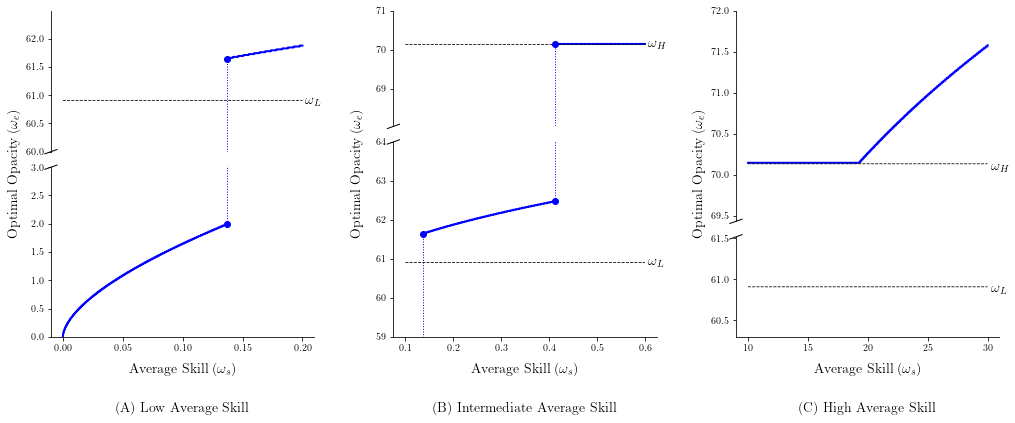

In [33]:
## Plot the result 
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})
y_lim_a = [min(we_star_a)*0.98, 3, 60,max(we_star_a)*1.01]  # Panel A (small skill average)
y_lim_b = [59, 64, cross_tl*0.97, 71,5]  # Panel B (intermediate skill average)
#y_lim_b = [wL_f*0.92, wL_f*1.12,  wH_f*0.97,  wH_f*1.05]
y_lim_c = [cross_th*0.99, cross_th*1.01 , cross_tl*0.99, 72] # Panel C (high skill average)

fig = plt.figure(figsize=(17, 6))
gs_main = fig.add_gridspec(1, 3, wspace=0.3)

# --- Panel A (Left) ---
loc1 = 'lower right'
ratio_a = [y_lim_a[3] - y_lim_a[2], y_lim_a[1] - y_lim_a[0]]
gs_a = gs_main[0, 0].subgridspec(2, 1, height_ratios=ratio_a, hspace=0.1)
ax_a_top = fig.add_subplot(gs_a[0, 0])
ax_a_bot = fig.add_subplot(gs_a[1, 0], sharex=ax_a_top)
draw_broken_axis(ax_a_top, ax_a_bot, ws_grid_a, we_star_a,  "Panel A", y_lim_a, r , loc1)
ax_a_top.plot(ws_grid_a, np.ones(len(ws_grid_a))*cross_th,'k--', lw = 0.8, alpha=1., label = r'$\omega_H$')
ax_a_top.plot(ws_grid_a, np.ones(len(ws_grid_a))*cross_tl,'k--', lw = 0.8, alpha=1., label = r'$\omega_H$')
ax_a_top.text(max(ws_grid_a)*1.01, cross_th*0.999, r'$\omega_L$', fontsize = 14)
ax_a_all = fig.add_subplot(gs_a[:], frameon=False)
ax_a_all.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_a_all.set_ylabel(r"Optimal Opacity ($\omega_e$)", fontsize=14, labelpad=10) # labelpadで軸との距離を調整
ax_a_bot.set_xlabel(r"Average Skill ($\omega_s$)", fontsize=14, labelpad=10)
ax_a_all.set_title(r"(A) Low Average Skill", y = -0.25, fontsize=14)



# --- Panel B (Middle) ---
loc3 = 'center right'
ratio_b = [y_lim_b[3] - y_lim_b[2], y_lim_b[1] - y_lim_b[0]]
gs_b = gs_main[0, 1].subgridspec(2, 1, height_ratios=ratio_b, hspace=0.1)
ax_b_top = fig.add_subplot(gs_b[0, 0])
ax_b_bot = fig.add_subplot(gs_b[1, 0], sharex=ax_b_top)
draw_broken_axis(ax_b_top, ax_b_bot, ws_grid_b, we_star_b, "", y_lim_b, r, loc3)
ax_b_bot.plot(ws_grid_b, np.ones(len(ws_grid_b))*cross_th,'k--', lw = 0.8, alpha=1., label = r'$\omega_H$')
ax_b_top.plot(ws_grid_b, np.ones(len(ws_grid_b))*cross_tl,'k--', lw = 0.8, alpha=1., label = r'$\omega_H$')
ax_b_bot.text(max(ws_grid_b)*1.01, cross_th*0.999, r'$\omega_L$', fontsize = 14)
ax_b_top.text(max(ws_grid_b)*1.01, cross_tl*0.999, r'$\omega_H$', fontsize = 14)
ax_b_all = fig.add_subplot(gs_b[:], frameon=False)
ax_b_all.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_b_all.set_ylabel(r"Optimal Opacity ($\omega_e$)", fontsize=14, labelpad=10) # labelpadで軸との距離を調整
ax_b_bot.set_xlabel(r"Average Skill ($\omega_s$)", fontsize=14, labelpad=10)
ax_b_all.set_title(r"(B) Intermediate Average Skill", y = -0.25, fontsize=14)

# --- Panel C (Right) ---
loc3 = 'center right'
ratio_c = [y_lim_c[3] - y_lim_c[2], y_lim_c[1] - y_lim_c[0]]
gs_c = gs_main[0, 2].subgridspec(2, 1, height_ratios=ratio_c, hspace=0.1)
ax_c_top = fig.add_subplot(gs_c[0, 0])
ax_c_bot = fig.add_subplot(gs_c[1, 0], sharex=ax_c_top)
draw_broken_axis(ax_c_top, ax_c_bot, ws_grid_c, we_star_c, "", y_lim_c, r, loc3)
ax_c_bot.plot(ws_grid_c, np.ones(len(ws_grid_c))*cross_th,'k--', lw = 0.8, alpha=1., label = r'$\omega_H$')
ax_c_top.plot(ws_grid_c, np.ones(len(ws_grid_c))*cross_tl,'k--', lw = 0.8, alpha=1., label = r'$\omega_H$')
ax_c_bot.text(max(ws_grid_c)*1.01, cross_th*0.999, r'$\omega_L$', fontsize = 14)
ax_c_top.text(max(ws_grid_c)*1.01, cross_tl*0.999, r'$\omega_H$', fontsize = 14)
ax_c_all = fig.add_subplot(gs_c[:], frameon=False)
ax_c_all.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_c_all.set_ylabel(r"Optimal Opacity ($\omega_e$)", fontsize=14, labelpad=10) # labelpadで軸との距離を調整
ax_c_bot.set_xlabel(r"Average Skill ($\omega_s$)", fontsize=14, labelpad=10)
ax_c_all.set_title(r"(C) High Average Skill ", y = -0.25, fontsize=14)


save_dir = "/Users/junaoyagi/Dropbox/Reputation/GitDelegation/6825e26759ced42dba694fbd/Figures/"
file_name = "fig_skill_optimal_opacity.png" # ここを "XXX.png" など自由に変更してください

# フォルダが存在しない場合に作成（エラー防止）
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 保存実行
save_path = os.path.join(save_dir, file_name)
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved to: {save_path}")

plt.show()